# Stage 2 — latent flow matching: generation and evaluation

Unconditional samples from the CondOT flow matching models trained on Model A (MSE) and Model B (zone-weighted spectral) latents. Reproduces Tables 1 and 3 and Figs. 6–8.

Run from `generation/notebooks/`. Requires the VAE checkpoints in `checkpoints/compression/`, FM checkpoints in `checkpoints/generation/`, and training latents in `data/latents/`.

In [1]:
import os, sys
import warnings
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

sys.path.append("../..")   # repository root
from compression.spectral import isotropic_spectrum
from generation.sampling import (Z_CHANNELS, load_vae, load_fm, euler, heun, rk4,
                                 decode_batched, calibrate_scale, time_solver)
from generation.structure_functions import compute_sf_ensemble

## Configuration

In [2]:
DATA_PATH  = "../../data/trajectory_real.npy"
LATENT_DIR = "../../data/latents"
VAE_DIR    = "../../checkpoints/compression"
FM_DIR     = "../../checkpoints/generation"
SAVE_DIR   = "../../results/generation"
os.makedirs(SAVE_DIR, exist_ok=True)

SEED      = 0
N_CAL     = 500     # draws used to fit the prior scale T
N_GEN     = 1000    # generated samples per model
k_dealias = 85
eps       = 1e-30
FS        = 13

RUN_SOLVER_STUDY = False   # Fig. 7; slow
RUN_STRUCTURE_FN = True    # Fig. 8

# tag -> VAE checkpoint name (FM checkpoint is best_fm_<name>.pt)
MODELS = {
    "A": "A_lat16_mse",
    "B": "B_lat16_weighted_mse_spec",
}
ROW_LABELS = {"A": "A (MSE)", "B": "B (MSE+Spec)"}

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Data and reference spectra

In [3]:
data      = np.load(DATA_PATH)
train_raw = data[1000:5500]
mu, sigma = train_raw.mean(), train_raw.std()
true_np   = data[5500:5500 + N_GEN]      # test set (500 fields available)

Et, k_arr = [], None
for f in true_np:
    E, k_arr = isotropic_spectrum(f)
    Et.append(E)
Et      = np.stack(Et)
Et_mean = Et.mean(0)

ir_mask = (k_arr >= 6) & (k_arr <= 40)
do_mask = (k_arr > 40) & (k_arr <= 65)
dd_mask = (k_arr > 65) & (k_arr <= 85)
print(f"True spectra: {Et.shape}")

True spectra: (500, 128)


## Models

In [4]:
vaes, fm_models, lat_std = {}, {}, {}
for tag, name in MODELS.items():
    vaes[tag]      = load_vae(f"{VAE_DIR}/best_{name}.pt", device)        # (vae, mu, sigma)
    fm_models[tag] = load_fm(f"{FM_DIR}/best_fm_{name}.pt", device, circular_pad=True)
    lat_std[tag]   = np.load(f"{LATENT_DIR}/train_latents_{name}.npy").std()
print("Models loaded.")


def zone_bias(spec, ref):
    """Mean and spread of log10(spec / ref) per zone."""
    lr = np.log10((spec + eps) / (ref + eps))
    return [f(lr[:, m]) for m in (ir_mask, do_mask, dd_mask) for f in (np.mean, np.std)]


def print_table(spectra, title, paired=False):
    """paired: spec[i] vs Et[i] (reconstruction). Unpaired: spec[i] vs mean true spectrum (generation)."""
    print(f"\n{title}\n")
    print(f"{'Pipeline':<16s}  {'IR bias':>9s}  {'IR sprd':>8s}  {'DO bias':>9s}  {'DO sprd':>8s}"
          f"  {'DD bias':>9s}  {'DD sprd':>8s}")
    print("-" * 80)
    for tag in MODELS:
        ref = Et[:len(spectra[tag])] if paired else Et_mean[None, :]
        ir_b, ir_s, do_b, do_s, dd_b, dd_s = zone_bias(spectra[tag], ref)
        print(f"  {ROW_LABELS[tag]:<14s}  {ir_b:>+9.4f}  {ir_s:>8.4f}  {do_b:>+9.4f}  {do_s:>8.4f}"
              f"  {dd_b:>+9.4f}  {dd_s:>8.4f}")


def generate(tag, n, scale=1.0, solver=euler, n_steps=100):
    vae, m, s = vaes[tag]
    z0 = torch.randn(n, Z_CHANNELS, 16, 16, device=device) * scale
    return decode_batched(vae.decoder, solver(fm_models[tag], z0, n_steps), s, m)


def spectra_of(fields):
    return np.stack([isotropic_spectrum(f)[0] for f in fields])

Models loaded.


## Table 1 — VAE reconstruction bias (paired)

In [5]:
test_norm = (true_np - mu) / (sigma + 1e-9)
BS = 10

recon_spectra = {}
with torch.no_grad():
    for tag, (vae, m, s) in vaes.items():
        E_list = []
        for i in range(0, len(test_norm), BS):
            xb = torch.tensor(test_norm[i:i + BS, None], dtype=torch.float32, device=device)
            xhat_np = vae.decoder(vae.encoder(xb)[0])[:, 0].cpu().numpy() * s + m
            E_list += [isotropic_spectrum(f)[0] for f in xhat_np]
        recon_spectra[tag] = np.stack(E_list)

print_table(recon_spectra, "VAE reconstruction spectral bias", paired=True)


VAE reconstruction spectral bias

Pipeline            IR bias   IR sprd    DO bias   DO sprd    DD bias   DD sprd
--------------------------------------------------------------------------------
  A (MSE)           -0.0430    0.0493    -0.2693    0.1119    -0.6060    0.1894
  B (MSE+Spec)      -0.0127    0.0310    -0.0338    0.0599    -0.0292    0.1087


## Generation without prior scaling, $z_0 \sim \mathcal{N}(0, I)$

In [6]:
spectra_raw = {}
print(f"{'Pipeline':<16s}  {'gen std':>8s}  {'true std':>8s}")
for tag in MODELS:
    gen = generate(tag, N_GEN)
    spectra_raw[tag] = spectra_of(gen)
    print(f"  {ROW_LABELS[tag]:<14s}  {gen.std():>8.4f}  {true_np.std():>8.4f}")

print_table(spectra_raw, "Spectral bias — no T-scaling")

Pipeline           gen std  true std
  A (MSE)           3.9641    4.5607
  B (MSE+Spec)      3.9961    4.5607

Spectral bias — no T-scaling

Pipeline            IR bias   IR sprd    DO bias   DO sprd    DD bias   DD sprd
--------------------------------------------------------------------------------
  A (MSE)           -0.4138    0.1889    -0.8487    0.1613    -1.2088    0.2051
  B (MSE+Spec)      -0.3207    0.1434    -0.4291    0.1157    -0.4310    0.1295


## Table 3 — generation with prior scaling, $z_0 \sim \mathcal{N}(0, T^2 I)$

In [7]:
spectra_cal, T_values, gen_fields = {}, {}, {}
print(f"{'Pipeline':<16s}  {'lat std':>8s}  {'T':>6s}  {'gen std':>8s}  {'true std':>8s}")
for tag in MODELS:
    T_values[tag]    = calibrate_scale(fm_models[tag], lat_std[tag], device, n_cal=N_CAL)
    gen_fields[tag]  = generate(tag, N_GEN, scale=T_values[tag])
    spectra_cal[tag] = spectra_of(gen_fields[tag])
    print(f"  {ROW_LABELS[tag]:<14s}  {lat_std[tag]:>8.4f}  {T_values[tag]:>6.4f}"
          f"  {gen_fields[tag].std():>8.4f}  {true_np.std():>8.4f}")

print_table(spectra_cal, "Spectral bias — with T-scaling")

Pipeline           lat std       T   gen std  true std
  A (MSE)           0.9244  1.1532    4.4591    4.5607
  B (MSE+Spec)      0.9472  1.1732    4.4704    4.5607

Spectral bias — with T-scaling

Pipeline            IR bias   IR sprd    DO bias   DO sprd    DD bias   DD sprd
--------------------------------------------------------------------------------
  A (MSE)           -0.1033    0.1274    -0.3681    0.1346    -0.7122    0.1955
  B (MSE+Spec)      -0.0279    0.1054    -0.0938    0.1005    -0.0903    0.1103


## Fig. 6 (top) — qualitative samples

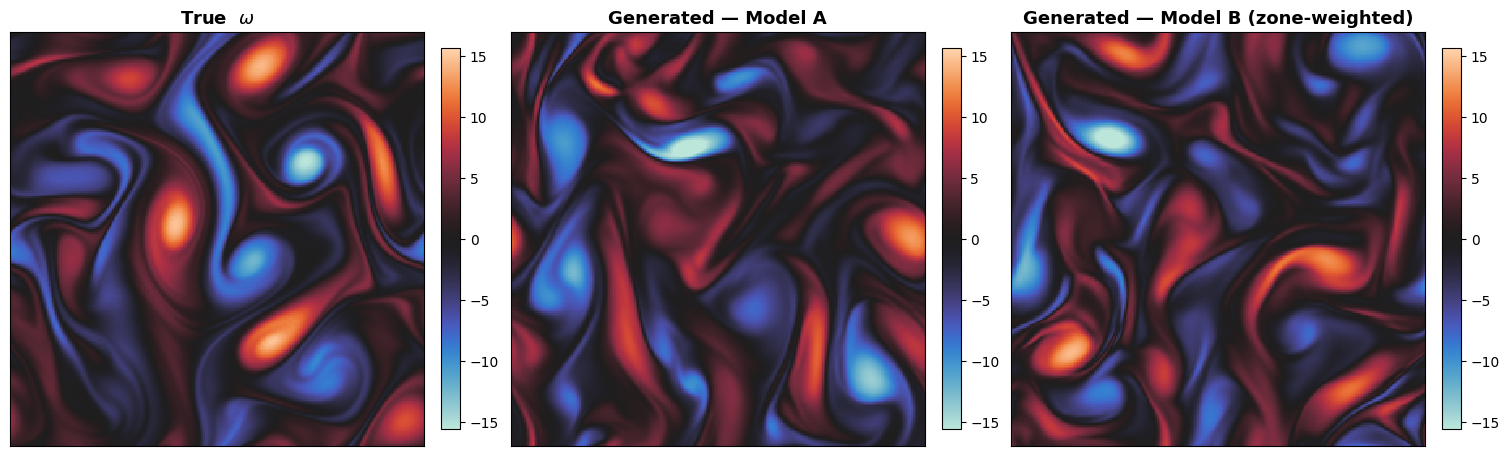

In [8]:
cmap_full = sns.color_palette("icefire", as_cmap=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
vmax = np.abs(true_np[0]).max()
for ax, field, title in zip(axes,
                            [true_np[0], gen_fields["A"][0], gen_fields["B"][0]],
                            [r"True  $\omega$", "Generated — Model A", "Generated — Model B (zone-weighted)"]):
    im = ax.imshow(field, cmap=cmap_full, vmin=-vmax, vmax=vmax, origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(xticks=[], yticks=[])
    ax.set_title(title, fontsize=FS, fontweight="bold")

plt.savefig(f"{SAVE_DIR}/fig_gen_qualitative.png", dpi=150, bbox_inches="tight")
plt.show()

## Fig. 6 (bottom) — generated spectra and bias

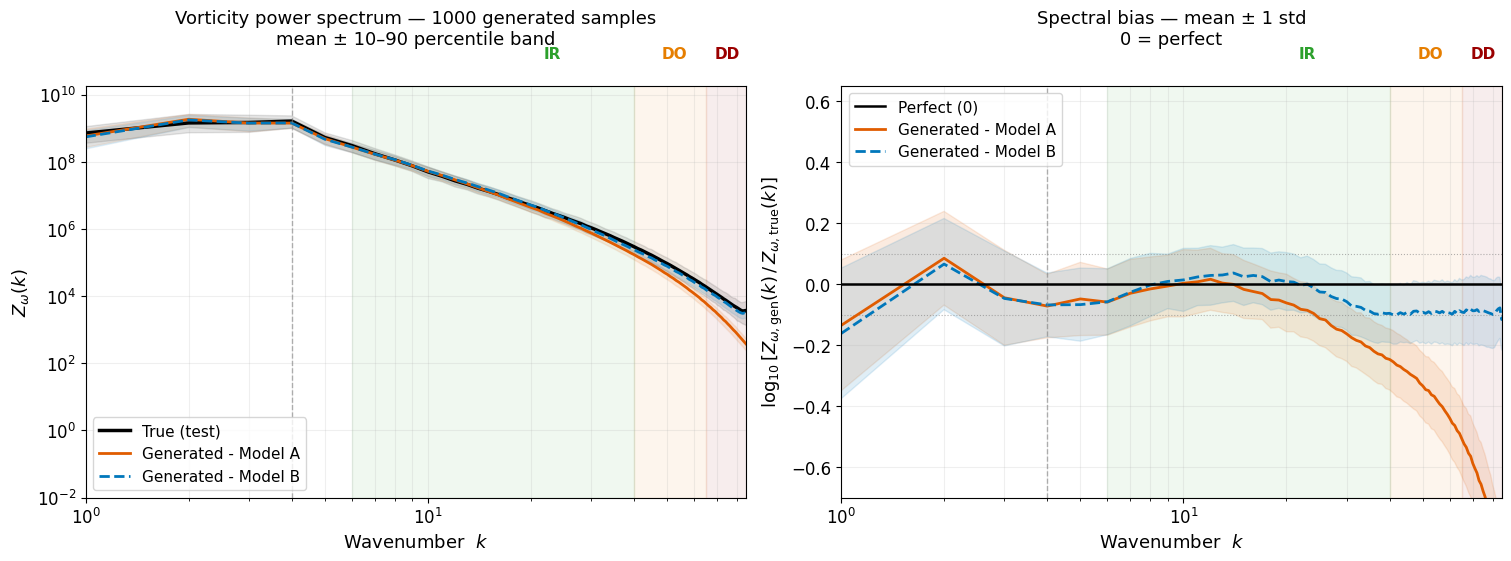

In [9]:
STYLES = {"true": ("black", "-", 2.5), "A": ("#e05c00", "-", 2.0), "B": ("#0077bb", "--", 2.0)}
LABELS = {"true": "True (test)", "A": "Generated - Model A", "B": "Generated - Model B"}
ZONES = {
    "inertial": dict(k_lo=6,  k_hi=40, label="IR", color="#2ca02c"),
    "mid":      dict(k_lo=40, k_hi=65, label="DO", color="#e67e00"),
    "high_k":   dict(k_lo=65, k_hi=85, label="DD", color="#9b0000"),
}

def add_zones(ax, pad=1.06):
    for z in ZONES.values():
        ax.axvspan(z["k_lo"], z["k_hi"], alpha=0.07, color=z["color"], zorder=0)
        ax.text((z["k_lo"] + z["k_hi"]) / 2, pad, z["label"], transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=11, color=z["color"], fontweight="bold")
    ax.axvline(4, color="gray", lw=1.0, ls="--", alpha=0.6)
    ax.tick_params(labelsize=12)
    ax.grid(True, which="both", alpha=0.2)

fig, (ax_spec, ax_bias) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

for key, E in [("true", Et), ("A", spectra_cal["A"]), ("B", spectra_cal["B"])]:
    c, ls, lw = STYLES[key]
    ax_spec.loglog(k_arr, E.mean(0), color=c, lw=lw, ls=ls, label=LABELS[key])
    ax_spec.fill_between(k_arr, np.percentile(E, 10, axis=0), np.percentile(E, 90, axis=0), color=c, alpha=0.10)
add_zones(ax_spec)
ax_spec.set_xlim(1, k_dealias); ax_spec.set_ylim(1e-2, None)
ax_spec.set_xlabel("Wavenumber  $k$", fontsize=FS)
ax_spec.set_ylabel(r"$Z_\omega(k)$", fontsize=FS)
ax_spec.set_title(f"Vorticity power spectrum — {N_GEN} generated samples\nmean ± 10–90 percentile band",
                  fontsize=FS, pad=30)
ax_spec.legend(fontsize=11, loc="lower left")

ax_bias.axhline(0, color="black", lw=1.8, label="Perfect (0)", zorder=5)
for y in (0.1, -0.1):
    ax_bias.axhline(y, color="gray", lw=0.8, ls=":", alpha=0.6)
for key in ("A", "B"):
    c, ls, lw = STYLES[key]
    lr = np.log10((spectra_cal[key] + eps) / (Et_mean[None, :] + eps))
    ax_bias.semilogx(k_arr, lr.mean(0), color=c, lw=lw, ls=ls, label=LABELS[key])
    ax_bias.fill_between(k_arr, lr.mean(0) - lr.std(0), lr.mean(0) + lr.std(0), color=c, alpha=0.12)
add_zones(ax_bias)
ax_bias.set_xlim(1, k_dealias); ax_bias.set_ylim(-0.7, 0.65)
ax_bias.set_xlabel("Wavenumber  $k$", fontsize=FS)
ax_bias.set_ylabel(r"$\log_{10}[Z_{\omega,\mathrm{gen}}(k)\,/\,Z_{\omega,\mathrm{true}}(k)]$", fontsize=FS)
ax_bias.set_title("Spectral bias — mean ± 1 std\n0 = perfect", fontsize=FS, pad=30)
ax_bias.legend(fontsize=11, loc="upper left")

plt.savefig(f"{SAVE_DIR}/fig_gen_spectra.png", dpi=150, bbox_inches="tight")
plt.show()

## Fig. 7 — sampling cost vs. fidelity

Set `RUN_SOLVER_STUDY = True` to run. RK4 is computed and printed but omitted from the figure (indistinguishable from Heun at equal NFE).

In [10]:
if RUN_SOLVER_STUDY:
    SOLVERS = [("euler", euler, [5, 10, 20, 50, 100, 200, 500], 1),
               ("heun",  heun,  [3, 5, 10, 25, 50, 100, 250],   2),
               ("rk4",   rk4,   [2, 3, 5, 13, 25, 50, 125],     4)]

    results = {tag: {s: {"nfe": [], "ir": [], "do": [], "dd": []} for s, *_ in SOLVERS} for tag in MODELS}
    print("Running solver study ...")
    for tag in MODELS:
        for sname, fn, steps_list, mult in SOLVERS:
            for n_steps in steps_list:
                ir_b, _, do_b, _, dd_b, _ = zone_bias(spectra_of(
                    generate(tag, N_GEN, scale=T_values[tag], solver=fn, n_steps=n_steps)), Et_mean[None, :])
                r = results[tag][sname]
                r["nfe"].append(n_steps * mult); r["ir"].append(ir_b); r["do"].append(do_b); r["dd"].append(dd_b)
                print(f"  {tag}  {sname:<5s}  NFE={n_steps*mult:4d}  IR={ir_b:+.3f}  DO={do_b:+.3f}  DD={dd_b:+.3f}")

    print("\nTiming solvers (batch=50, Model B) ...")
    z0_bench, ms_per_nfe = torch.randn(50, Z_CHANNELS, 16, 16, device=device), []
    for sname, fn, steps_list, mult in SOLVERS:
        n_steps = steps_list[2]
        t_mean, t_std = time_solver(fn, fm_models["B"], z0_bench, n_steps)
        ms_per_nfe.append(t_mean / (n_steps * mult))
        print(f"  {sname:<5s}  NFE={n_steps*mult:3d}  {t_mean:.1f}±{t_std:.1f} ms  ({ms_per_nfe[-1]:.2f} ms/NFE)")
    print(f"  Mean wall-clock: {np.mean(ms_per_nfe):.2f} ms/NFE")

    STYLE = {"A": "#e05c00", "B": "#0077bb"}
    SOLVER_STYLE = {"euler": ("-", "o", "Euler"), "heun": ("--", "s", "Heun")}
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
    for ax, zkey in zip(axes, ["dd", "do", "ir"]):
        ax.axhline(0, color="black", lw=1.0, ls="--", alpha=0.4, zorder=0)
        for tag in MODELS:
            for sname, (ls, mk, slabel) in SOLVER_STYLE.items():
                r = results[tag][sname]
                ax.plot(r["nfe"], r[zkey], color=STYLE[tag], ls=ls, lw=1.8, marker=mk, markersize=5,
                        label=f"Model {tag} — {slabel}")
        ax.set_xscale("log")
        ax.set_xlabel("NFE", fontsize=FS)
        ax.set_ylabel(rf"$\log_{{10}}[Z_{{\omega,\mathrm{{gen}}}}/Z_{{\omega,\mathrm{{true}}}}]$ — {zkey.upper()}", fontsize=FS)
        ax.set_title(f"{zkey.upper()} spectral bias", fontsize=FS)
        ax.tick_params(labelsize=11)
        ax.grid(True, which="both", alpha=0.2)
    axes[0].legend(fontsize=10, loc="lower right")
    plt.savefig(f"{SAVE_DIR}/fig_solver_study.png", dpi=150, bbox_inches="tight")
    plt.show()

## Fig. 8 — longitudinal structure functions

Computing structure functions (500 fields, 24 angles) ...
true ensemble ...
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done
A ensemble ...
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done
B ensemble ...
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done


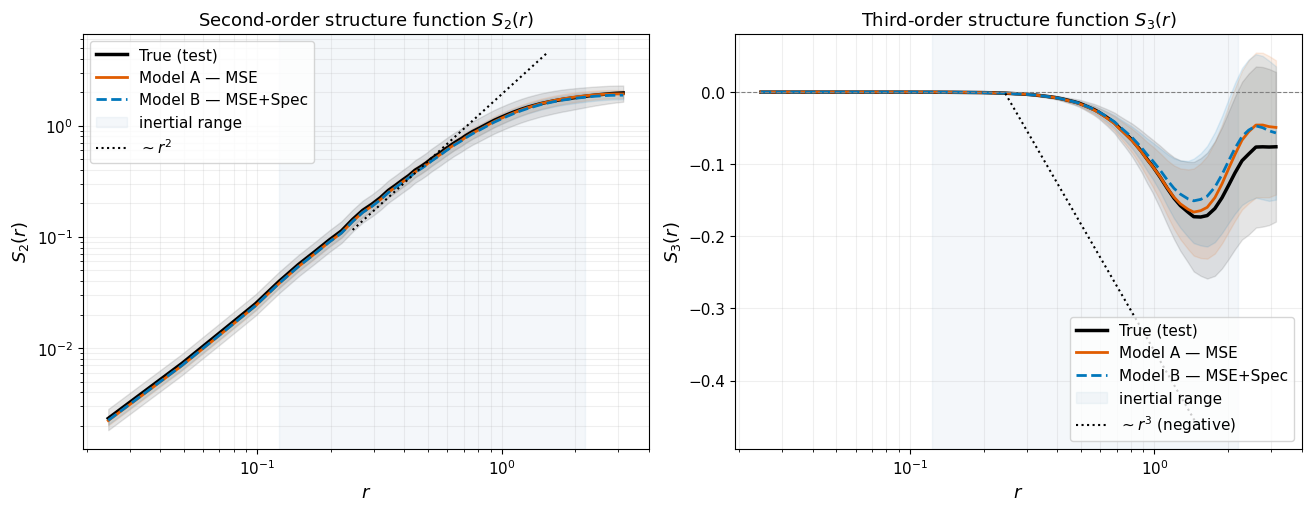


Ensemble                S2 IR mean    S3 IR mean  S3 IR sign
------------------------------------------------------------
  True (test)           8.3375e-01   -6.4825e-02  negative ✓
  Model A — MSE         8.2328e-01   -6.1978e-02  negative ✓
  Model B — MSE+Spec    8.0914e-01   -5.6902e-02  negative ✓


In [11]:
if RUN_STRUCTURE_FN:
    N_SF, N_ANGLES = 500, 24
    print(f"Computing structure functions ({N_SF} fields, {N_ANGLES} angles) ...")
    SF = {}
    for key, fields in [("true", true_np), ("A", gen_fields["A"]), ("B", gen_fields["B"])]:
        print(f"{key} ensemble ...")
        r_phys, SF[key] = compute_sf_ensemble(fields, n_fields=N_SF, n_angles=N_ANGLES)

    L = 2.0 * np.pi
    dx_phys = L / true_np.shape[1]
    ir_lo, ir_hi = 5 * dx_phys, 0.35 * L
    ir_sf = (r_phys > ir_lo) & (r_phys < ir_hi)
    i_anc = np.argmin(np.abs(r_phys - 0.08 * L))
    r_ref = np.array([ir_lo * 2, ir_hi * 0.7])
    C2 = SF["true"][2].mean(0)[i_anc] / r_phys[i_anc]**2
    C3 = SF["true"][3].mean(0)[i_anc] / r_phys[i_anc]**3      # negative

    LABELS_SF = {"true": "True (test)", "A": "Model A — MSE", "B": "Model B — MSE+Spec"}
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    for ax, p, plot in [(axes[0], 2, "loglog"), (axes[1], 3, "semilogx")]:
        for key in ("true", "A", "B"):
            c, ls, lw = STYLES[key]
            mean, std = SF[key][p].mean(0), SF[key][p].std(0)
            getattr(ax, plot)(r_phys, mean, color=c, lw=lw, ls=ls, label=LABELS_SF[key])
            ax.fill_between(r_phys, mean - std, mean + std, color=c, alpha=0.10)
        ax.axvspan(ir_lo, ir_hi, alpha=0.06, color="steelblue", zorder=0, label="inertial range")
        ax.set_xlabel(r"$r$", fontsize=FS)
        ax.set_ylabel(rf"$S_{p}(r)$", fontsize=FS)
        ax.tick_params(labelsize=11)
        ax.grid(True, which="both", alpha=0.2)

    axes[0].loglog(r_ref, C2 * r_ref**2, "k:", lw=1.5, label=r"$\sim r^2$")
    axes[0].set_title(r"Second-order structure function $S_2(r)$", fontsize=FS)
    axes[0].legend(fontsize=11, loc="upper left")
    if abs(C3) > 1e-12:
        axes[1].semilogx(r_ref, C3 * r_ref**3, "k:", lw=1.5, label=r"$\sim r^3$ (negative)")
    axes[1].axhline(0, color="gray", lw=0.8, ls="--")
    axes[1].set_title(r"Third-order structure function $S_3(r)$", fontsize=FS)
    axes[1].legend(fontsize=11, loc="lower right")

    plt.savefig(f"{SAVE_DIR}/fig_structure_functions.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n{'Ensemble':<20s}  {'S2 IR mean':>12s}  {'S3 IR mean':>12s}  {'S3 IR sign':>10s}")
    print("-" * 60)
    for key in ("true", "A", "B"):
        s2, s3 = SF[key][2][:, ir_sf].mean(), SF[key][3][:, ir_sf].mean()
        print(f"  {LABELS_SF[key]:<18s}  {s2:>12.4e}  {s3:>12.4e}  {'negative ✓' if s3 < 0 else 'positive ✗'}")